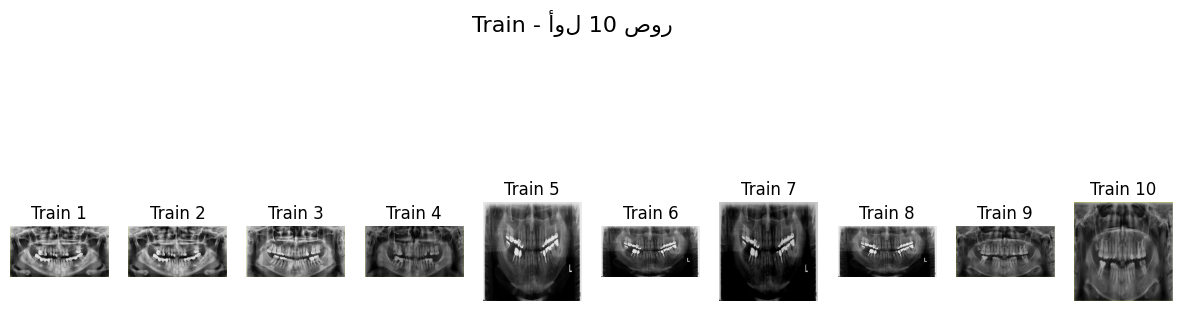

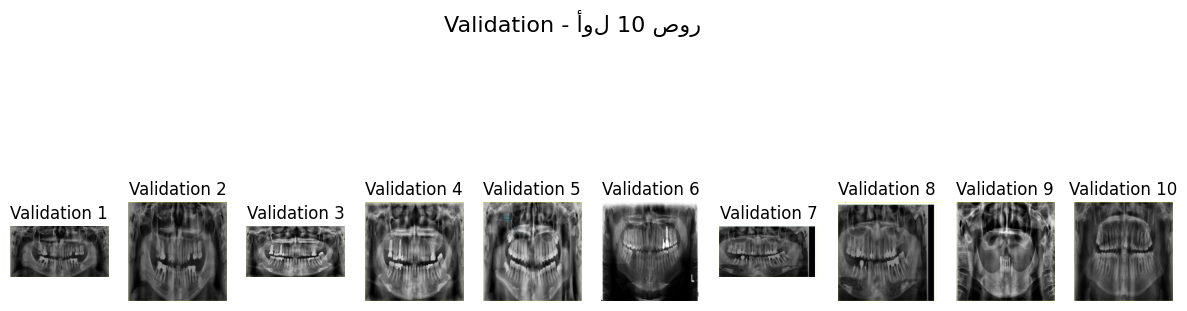

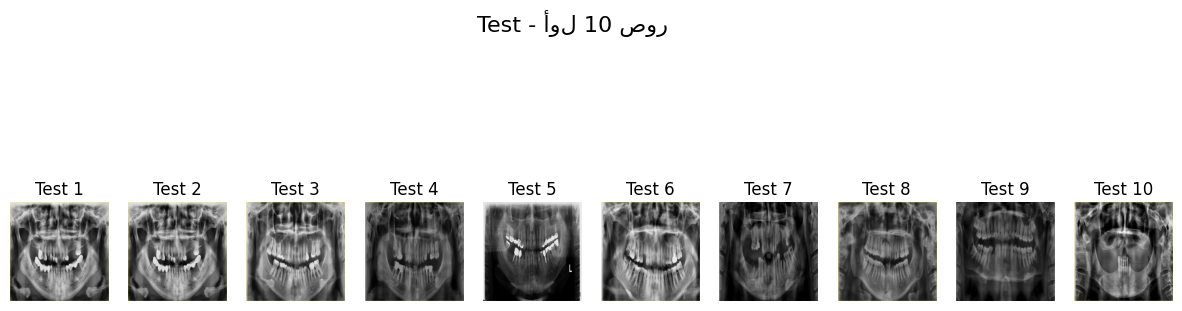

In [8]:
import os
from PIL import Image
import matplotlib.pyplot as plt

def show_images_from_folder(folder_path, title, max_images=10):
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    image_files = image_files[:max_images]

    plt.figure(figsize=(15, 5))
    for i, file in enumerate(image_files):
        img_path = os.path.join(folder_path, file)
        img = Image.open(img_path)

        plt.subplot(1, max_images, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{title} {i+1}")

    plt.suptitle(f"{title} - أول {max_images} صور", fontsize=16)
    plt.show()

# تعريف المسارات:
train_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\train\images"
val_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\valid\images"
test_path = r"C:\Users\LENOVO\Desktop\archive (1)\YOLO\YOLO\test\images"

# عرض الصور:
show_images_from_folder(train_path, "Train")
show_images_from_folder(val_path, "Validation")
show_images_from_folder(test_path, "Test")


In [ ]:
from google.colab import drive
import os
import cv2
import numpy as np
import pandas as pd

drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/dental_dataset/dental_dataset'
images_folder = os.path.join(dataset_path, "images", "train")
# images_folder = os.path.join(dataset_path, "images", "valid")

output_csv = os.path.join(dataset_path, "manual_features_train2.csv")

if not os.path.exists(images_folder):
    raise FileNotFoundError(f"Image folder not found: {images_folder}")


image_files = [f for f in os.listdir(images_folder) if f.lower().endswith((".jpg", ".png"))]
print(f"Number of images found: {len(image_files)}")

def extract_manual_features(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    features = {}
    features["mean_intensity"] = float(np.mean(img))

    features["std_intensity"] = float(np.std(img))

    dark_pixels = np.sum(img < np.percentile(img, 5))
    features["dark_pixel_count"] = int(dark_pixels)

    left_half = img[:, :img.shape[1] // 2]
    right_half = img[:, img.shape[1] // 2:]
    symmetry_score = abs(np.mean(left_half) - np.mean(right_half))
    features["symmetry_score"] = float(symmetry_score)

    hist, _ = np.histogram(img.flatten(), bins=256, range=(0, 256))
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-8))
    features["image_entropy"] = float(entropy)

    return features

features_list = []

for i, img_file in enumerate(image_files):
    print(f"[{i+1}/{len(image_files)}] Processing: {img_file}")
    try:
        img_path = os.path.join(images_folder, img_file)
        features = extract_manual_features(img_path)
        features["image_name"] = img_file
        features_list.append(features)
    except Exception as e:
        print(f"Error processing {img_file}: {str(e)}")
        continue

df = pd.DataFrame(features_list)
df.to_csv(output_csv, index=False)

print(f"\nFeatures saved to: {output_csv}")
print("First 5 rows:")
print(df.head())


In [ ]:

import os
import json
import torch
import torchvision
from torchvision.models.detection import fasterrcnn_resnet50_fpn_v2, FasterRCNN_ResNet50_FPN_V2_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torch.optim.lr_scheduler import OneCycleLR
from google.colab import drive
from sklearn.metrics import f1_score
import numpy as np
from torch.amp import autocast, GradScaler
import time
import sys

# تحسين أداء CUDA
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

# ربط Google Drive
drive.mount('/content/drive', force_remount=True)

# ------------------------------- 2. Dataset مخصص -------------------------------
class DentalDataset(Dataset):
    def __init__(self, json_path, image_dirs, transforms=None):
        with open(json_path, 'r') as f:
            self.coco = json.load(f)
        self.transforms = transforms
        self.image_dirs = image_dirs if isinstance(image_dirs, list) else [image_dirs]

        self.filename_to_path = {}
        for img_dir in self.image_dirs:
            if not os.path.exists(img_dir):
                continue
            for root, _, files in os.walk(img_dir):
                for file in files:
                    if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                        key = file.lower()
                        if key not in self.filename_to_path:
                            self.filename_to_path[key] = os.path.join(root, file)

        self.img_id_to_name = {img['id']: img['file_name'] for img in self.coco['images']}
        self.annotations_per_image = {}
        for ann in self.coco['annotations']:
            img_id = ann['image_id']
            if img_id not in self.annotations_per_image:
                self.annotations_per_image[img_id] = []
            self.annotations_per_image[img_id].append(ann)

        self.valid_images = {}
        for img in self.coco['images']:
            filename = img['file_name']
            if filename.lower() in self.filename_to_path:
                self.valid_images[img['id']] = {'filename': filename, 'path': self.filename_to_path[filename.lower()]}

        self.category_mapping = {cat['id']: cat['name'] for cat in self.coco['categories']}
        sorted_ids = sorted(self.category_mapping.keys())
        self.id_to_continuous = {old_id: i for i, old_id in enumerate(sorted_ids)}
        self.continuous_to_original = {i: old_id for i, old_id in enumerate(sorted_ids)}
        self.num_classes = len(self.category_mapping)

        print(f"[INFO] Loaded {len(self.valid_images)} images")
        print(f"[INFO] Number of classes: {self.num_classes}")

    def __len__(self):
        return len(self.valid_images)

    def __getitem__(self, idx):
        img_id = list(self.valid_images.keys())[idx]
        info = self.valid_images[img_id]
        image = Image.open(info['path']).convert("RGB")

        boxes = []
        labels = []
        for ann in self.annotations_per_image.get(img_id, []):
            x_min, y_min, w, h = ann['bbox']
            boxes.append([x_min, y_min, x_min + w, y_min + h])
            labels.append(self.id_to_continuous[ann['category_id']])

        boxes = torch.as_tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels, "image_id": torch.tensor(img_id)}

        if self.transforms:
            image = self.transforms(image)

        return image, target

# ------------------------------- 3. التحويلات -------------------------------
def get_transform(train=True):
    transforms = [T.Resize((640, 640))]
    if train: transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.extend([T.ToTensor(), T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])
    return T.Compose(transforms)

# ------------------------------- 4. مسارات الملفات -------------------------------
train_json = "/content/drive/MyDrive/dental_dataset/annotations/train_coco_fixed.json"
val_json   = "/content/drive/MyDrive/dental_dataset/annotations/valid_coco_fixed.json"
image_dirs = [
    "/content/drive/MyDrive/dental_dataset/images/train",
    "/content/drive/MyDrive/dental_dataset/images/valid",
    "/content/drive/MyDrive/dental_dataset/images/test"
]

# ------------------------------- 5. التحقق من GPU -------------------------------
def check_gpu():
    print("=== GPU Status Check ===")
    print(f"CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        gpu_name = torch.cuda.get_device_name(0)
        gpu_mem  = torch.cuda.get_device_properties(0).total_memory / 1024**3
        print(f"GPU: {gpu_name} | Memory: {gpu_mem:.1f} GB")
        device = torch.device("cuda")
    else:
        print(" No GPU available! Enable GPU in Colab")
        device = torch.device("cpu")
    return device

device = check_gpu()

# ------------------------------- 6. Datasets و Dataloaders -------------------------------
dataset_train = DentalDataset(train_json, image_dirs, transforms=get_transform(True))
dataset_val   = DentalDataset(val_json, image_dirs, transforms=get_transform(False))

data_loader_train = DataLoader(dataset_train, batch_size=6, shuffle=True, collate_fn=lambda x: tuple(zip(*x)), num_workers=2, pin_memory=device.type=='cuda', persistent_workers=True, prefetch_factor=2)
data_loader_val   = DataLoader(dataset_val, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)), num_workers=2, pin_memory=device.type=='cuda')

print(f"[INFO] Training on {len(dataset_train)} images")
print(f"[INFO] Validation on {len(dataset_val)} images")
print(f"[INFO] Using device: {device}")

# ------------------------------- 7. بناء النموذج -------------------------------
def get_model(num_classes):
    weights = FasterRCNN_ResNet50_FPN_V2_Weights.DEFAULT
    model = fasterrcnn_resnet50_fpn_v2(weights=weights, trainable_backbone_layers=3)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model = get_model(dataset_train.num_classes).to(device)

# ------------------------------- 8. حساب F1-Score -------------------------------
def compute_f1_score(targets, outputs, num_classes, threshold=0.5):
    y_true, y_pred = [], []
    for target, out in zip(targets, outputs):
        gt_labels = target['labels'].cpu().numpy()
        true_bin = np.zeros(num_classes)
        for l in gt_labels: true_bin[l]=1

        if len(out['boxes'])>0 and 'scores' in out:
            scores = out['scores'].cpu().numpy()
            pred_labels = out['labels'].cpu().numpy()
            pred_bin = np.zeros(num_classes)
            for l,s in zip(pred_labels,scores):
                if s>threshold: pred_bin[l]=1
        else: pred_bin = np.zeros(num_classes)

        y_true.append(true_bin)
        y_pred.append(pred_bin)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    if y_true.sum()==0 and y_pred.sum()==0: return 1.0
    elif y_true.sum()==0 or y_pred.sum()==0: return 0.0
    return f1_score(y_true, y_pred, average='samples')

# ------------------------------- 9. التدريب مع Mixed Precision -------------------------------
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.AdamW(params, lr=2e-4, weight_decay=0.05)
scheduler = OneCycleLR(optimizer, max_lr=2e-4, steps_per_epoch=len(data_loader_train), epochs=25, pct_start=0.1, anneal_strategy='cos')
scaler = GradScaler(device="cuda")

best_val_f1 = 0.0
patience = 8
patience_counter = 0
eval_every_n_epochs = 2

checkpoint_path = "/content/drive/MyDrive/dental_dataset/checkpoint.pth"
start_epoch = 0

# ------------------------------- استئناف التدريب إذا وجد Checkpoint -------------------------------
if os.path.exists(checkpoint_path):
    print("[INFO] Found checkpoint, loading...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    best_val_f1 = checkpoint.get('best_val_f1', 0.0)
    start_epoch = checkpoint.get('epoch', 0) + 1
    print(f"[INFO] Resuming training from epoch {start_epoch} | Best Val F1: {best_val_f1:.4f}")
else:
    print("[INFO] No checkpoint found, starting fresh training")

print(f"\n[INFO] Starting training on {device} with Mixed Precision")
start_time = time.time()

for epoch in range(start_epoch, 25):
    model.train()
    epoch_loss = 0.0
    epoch_start = time.time()
    print(f"\n===== Epoch {epoch+1}/25 =====")
    for batch_idx, (images, targets) in enumerate(data_loader_train,1):
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        optimizer.zero_grad()
        with autocast(device_type="cuda"):
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())

        scaler.scale(losses).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        epoch_loss += losses.item()

        if batch_idx%10==0 or batch_idx==len(data_loader_train):
            avg_loss = epoch_loss/batch_idx
            progress = 100*batch_idx/len(data_loader_train)
            elapsed = time.time()-epoch_start
            est_total = elapsed/batch_idx*len(data_loader_train)
            est_remain = est_total-elapsed
            sys.stdout.write(f"\rEpoch {epoch+1} | [{batch_idx}/{len(data_loader_train)} - {progress:.1f}%] Loss(avg): {avg_loss:.4f} | Elapsed: {elapsed/60:.1f}m | ETA: {est_remain/60:.1f}m")
            sys.stdout.flush()
    print()

    # حفظ Checkpoint بعد كل Epoch
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'best_val_f1': best_val_f1,
        'epoch': epoch,
        'class_mapping': dataset_train.category_mapping,
        'continuous_mapping': dataset_train.continuous_to_original,
        'pytorch_version': torch.__version__
    }, checkpoint_path)
    print(f" Checkpoint saved at epoch {epoch+1}")

    epoch_time = time.time()-epoch_start
    avg_loss = epoch_loss/len(data_loader_train)
    print(f"  Epoch {epoch+1} completed in {epoch_time/60:.1f} minutes | Avg Loss: {avg_loss:.4f}")

    if (epoch+1)%eval_every_n_epochs==0:
        model.eval()
        all_targets, all_outputs = [], []
        with torch.no_grad():
            for images, targets in data_loader_val:
                images = [img.to(device) for img in images]
                outputs = model(images)
                all_targets.extend(targets)
                all_outputs.extend(outputs)

        val_f1 = compute_f1_score(all_targets, all_outputs, dataset_train.num_classes)
        print(f" Epoch {epoch+1}/25 | Val F1: {val_f1:.4f}")

        if val_f1>best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'best_val_f1': best_val_f1,
                'epoch': epoch,
                'class_mapping': dataset_train.category_mapping,
                'continuous_mapping': dataset_train.continuous_to_original,
                'pytorch_version': torch.__version__
            }, "/content/drive/MyDrive/dental_dataset/complete_model.pth")
            print("💾 Best model saved with metadata")
            patience_counter=0
        else:
            patience_counter+=1
            print(f" No improvement: {patience_counter}/{patience}")
        if patience_counter>=patience:
            print(" Early stopping triggered")
            break

total_time = time.time()-start_time
print(f"\n Training completed in {total_time/3600:.1f} hours | Best Val F1: {best_val_f1:.4f}")

torch.save(model.state_dict(), "/content/drive/MyDrive/dental_dataset/final_model_weights.pth")
print(" Final model weights saved")
